<a href="https://colab.research.google.com/github/pollybond/MD-Data-Science/blob/master/%D0%9F%D1%80%D0%B5%D0%B4%D0%B8%D0%BA%D1%82%D0%B8%D0%B2%D0%BD%D0%B0%D1%8F_%D0%B0%D0%BD%D0%B0%D0%BB%D0%B8%D1%82%D0%B8%D0%BA%D0%B0_virtual_sensor_solution.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [52]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from sklearn.model_selection import TimeSeriesSplit
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
from sklearn.base import clone
from scipy.stats import shapiro
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.diagnostic import het_breuschpagan
from sklearn.inspection import permutation_importance
from statsmodels.graphics.tsaplots import plot_acf
import shap
import time
import statsmodels.api as sm
from scipy import stats

warnings.filterwarnings('ignore')
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [34]:
# Загрузка данных
df_telemetry = pd.read_csv('data_train.csv', parse_dates=['datetime'])
df_target = pd.read_csv('target_train.csv', parse_dates=['Дата'])
df_telemetry.rename(columns={'datetime': 'timestamp'}, inplace=True)
df_target.rename(columns={'Дата': 'timestamp'}, inplace=True)


print(f"Телеметрия: {df_telemetry.shape}")
print(f"Целевая переменная: {df_target.shape}")
print(df_telemetry.head())
print(df_target.head())

Телеметрия: (319546, 17)
Целевая переменная: (1773, 2)
            timestamp  telemetry_0  telemetry_1  telemetry_2  telemetry_3  \
0 2019-03-01 00:01:00     0.737538     0.478367     0.292816     0.644016   
1 2019-03-01 00:02:00     0.738406     0.478977     0.292816     0.648557   
2 2019-03-01 00:03:00     0.738985     0.478977     0.292816     0.647164   
3 2019-03-01 00:04:00     0.739563     0.478977     0.292816     0.636938   
4 2019-03-01 00:05:00     0.740431     0.477119     0.292816     0.635834   

   telemetry_4  telemetry_5  telemetry_6  telemetry_7  telemetry_8  \
0     0.919471     0.884814     0.754800     0.413295      0.47192   
1     0.919471     0.887129     0.752977     0.413295      0.47192   
2     0.919471     0.887129     0.755444     0.413295      0.47192   
3     0.919471     0.887129     0.754800     0.413295      0.47192   
4     0.919471     0.887707     0.754156     0.413295      0.47192   

   telemetry_9  telemetry_10  telemetry_11  telemetry_12  tel

# Разведочный анализ данных (EDA)

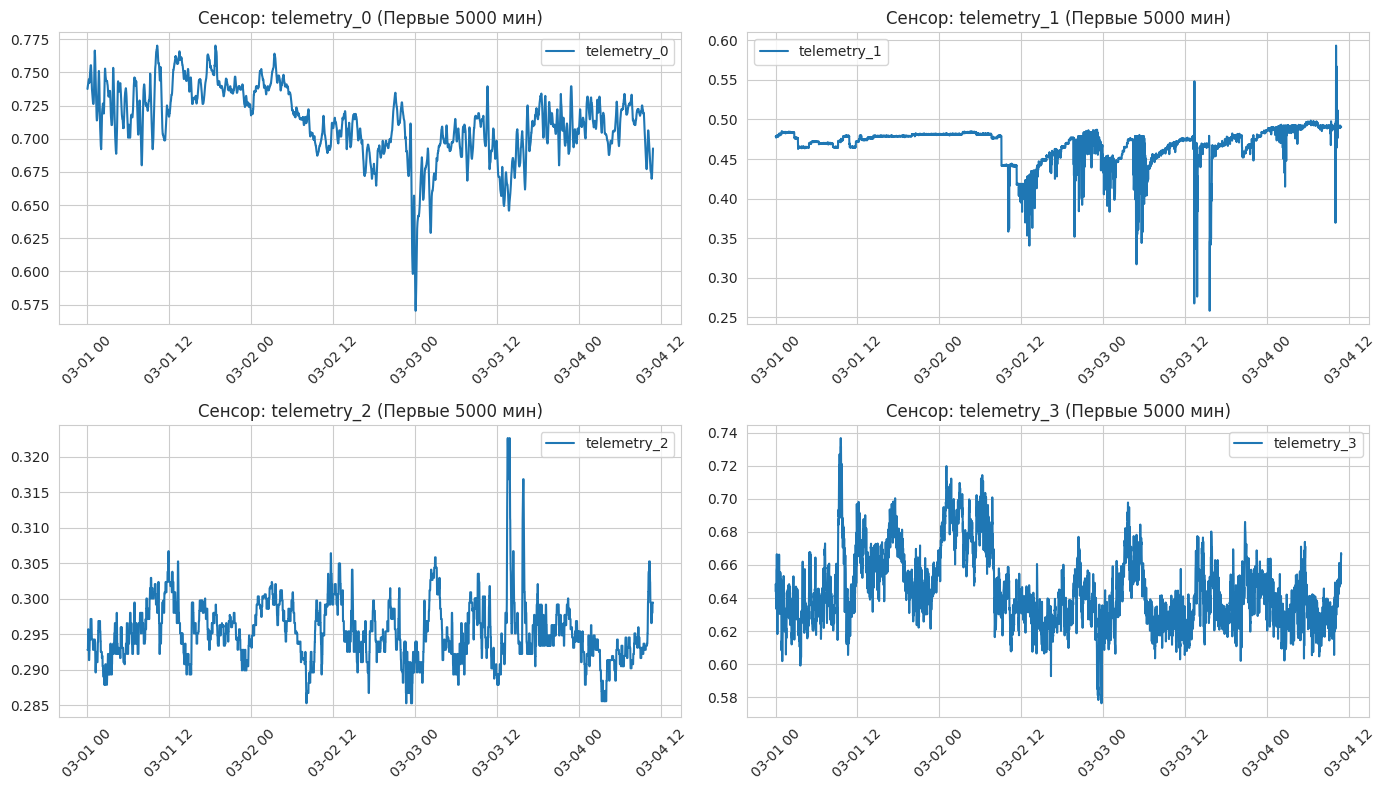

In [35]:
# Визуализация телеметрии
sensor_cols = [col for col in df_telemetry.columns if col not in ['timestamp']]
sample_sensors = sensor_cols[:4]

plt.figure(figsize=(14, 8))
for i, col in enumerate(sample_sensors):
    plt.subplot(2, 2, i+1)
    plt.plot(df_telemetry['timestamp'][:5000], df_telemetry[col][:5000], label=col)
    plt.title(f"Сенсор: {col} (Первые 5000 мин)")
    plt.xticks(rotation=45)
    plt.legend()
plt.tight_layout()
plt.show()


Аналитический вывод 1:

1. Выявлены аномалии: 2-3 марта все сенсоры показывают синхронные возмущения — вероятна нештатная ситуация или смена режима работы печи.

2. Разная динамика показателей:
telemetry_0 и telemetry_2 — относительно стабильные,
telemetry_1 — ступенчатые изменения с резкими выбросами,
telemetry_3 — постоянная высокая вариабельность

3. Требуют обработки: присутствуют выбросы и пропуски данных, необходима нормализация признаков.

4. Наблюдается инерционность: возмущения распространяются по сенсорам с задержкой, что обосновывает создание лаговых признаков.


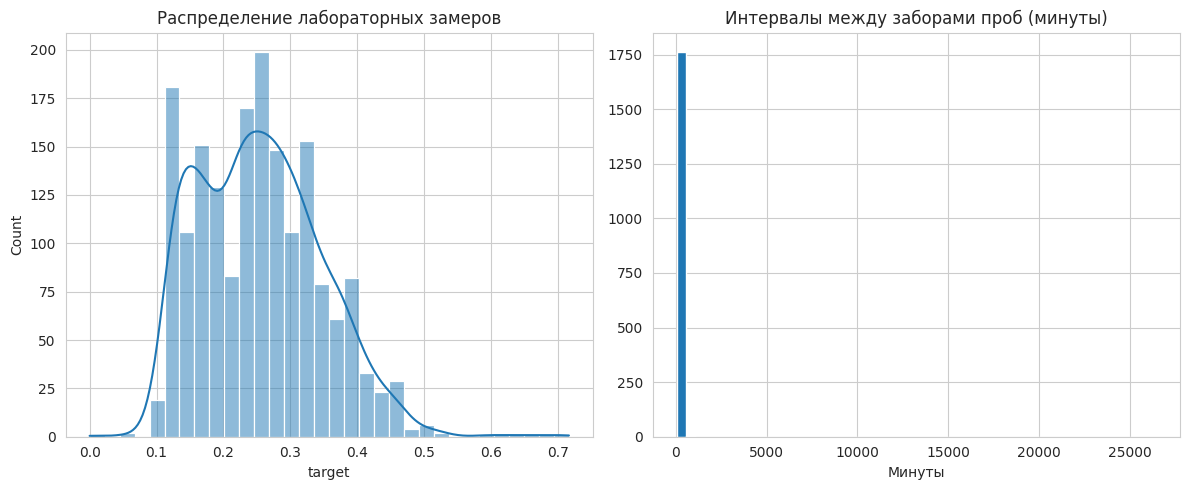

In [36]:
# Анализ целевой переменной
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.histplot(df_target['target'], kde=True)
plt.title("Распределение лабораторных замеров")

plt.subplot(1, 2, 2)
# Частота замеров
df_target['time_diff'] = df_target['timestamp'].diff()
plt.hist(df_target['time_diff'].dt.total_seconds() / 60, bins=50)
plt.title("Интервалы между заборами проб (минуты)")
plt.xlabel("Минуты")
plt.tight_layout()
plt.show()

Аналитический вывод 2:

1. Распределение концентрации:

Диапазон значений: 0.0–0.7

Распределение близкое к нормальному с пиками около 0.15 и 0.25–0.30

Основная масса замеров сконцентрирована в интервале 0.1–0.4


2. Частота отбора проб:

Интервалы между заборами проб крайне нерегулярные

Наблюдается аномально высокий пик near 0 минут (возможны дубликаты или ошибки в данных)

Требует дополнительной проверки качества данных


3. Вывод для моделирования:

Целевая переменная имеет разумный диапазон без экстремальных выбросов

Необходима очистка данных от аномальных интервалов перед обучением


In [37]:
# Синхронизация данных
# Сдвиг на 15 минут назад для учёта задержки анализа
DELAY_MINUTES = 15
df_target['aligned_timestamp'] = df_target['timestamp'] - pd.Timedelta(minutes=DELAY_MINUTES)
df_target['aligned_timestamp_rounded'] = df_target['aligned_timestamp'].dt.floor('T')

# Объединяем телеметрию с целевой переменной
df_merged = pd.merge(df_telemetry, df_target[['aligned_timestamp_rounded', 'target']],
                     left_on='timestamp', right_on='aligned_timestamp_rounded', how='left')

print(f"Объединенный датасет: {df_merged.shape}")
print(f"Количество строк с целевой переменной: {df_merged['target'].notnull().sum()}")
print(df_merged.head())

Объединенный датасет: (319546, 19)
Количество строк с целевой переменной: 1772
            timestamp  telemetry_0  telemetry_1  telemetry_2  telemetry_3  \
0 2019-03-01 00:01:00     0.737538     0.478367     0.292816     0.644016   
1 2019-03-01 00:02:00     0.738406     0.478977     0.292816     0.648557   
2 2019-03-01 00:03:00     0.738985     0.478977     0.292816     0.647164   
3 2019-03-01 00:04:00     0.739563     0.478977     0.292816     0.636938   
4 2019-03-01 00:05:00     0.740431     0.477119     0.292816     0.635834   

   telemetry_4  telemetry_5  telemetry_6  telemetry_7  telemetry_8  \
0     0.919471     0.884814     0.754800     0.413295      0.47192   
1     0.919471     0.887129     0.752977     0.413295      0.47192   
2     0.919471     0.887129     0.755444     0.413295      0.47192   
3     0.919471     0.887129     0.754800     0.413295      0.47192   
4     0.919471     0.887707     0.754156     0.413295      0.47192   

   telemetry_9  telemetry_10  telemet

Аналитический вывод 3:

1. Успешное объединение:

319 546 минутных записей телеметрии + 1 772 лабораторных замера

Доля размеченных данных: 0.55% — типично для задач с редкими целевыми измерениями

2. Корректность синхронизации:

Сдвиг на 15 минут назад для target учитывает задержку лабораторного анализа

Целевая переменная привязана к моменту отбора пробы, а не получения результата

3. Структура данных:

Большинство строк имеют target = NaN — обучение будет проводиться только на 1 772 размеченных примерах

Пропуски в telemetry_12–15 требуют обработки перед генерацией признаков

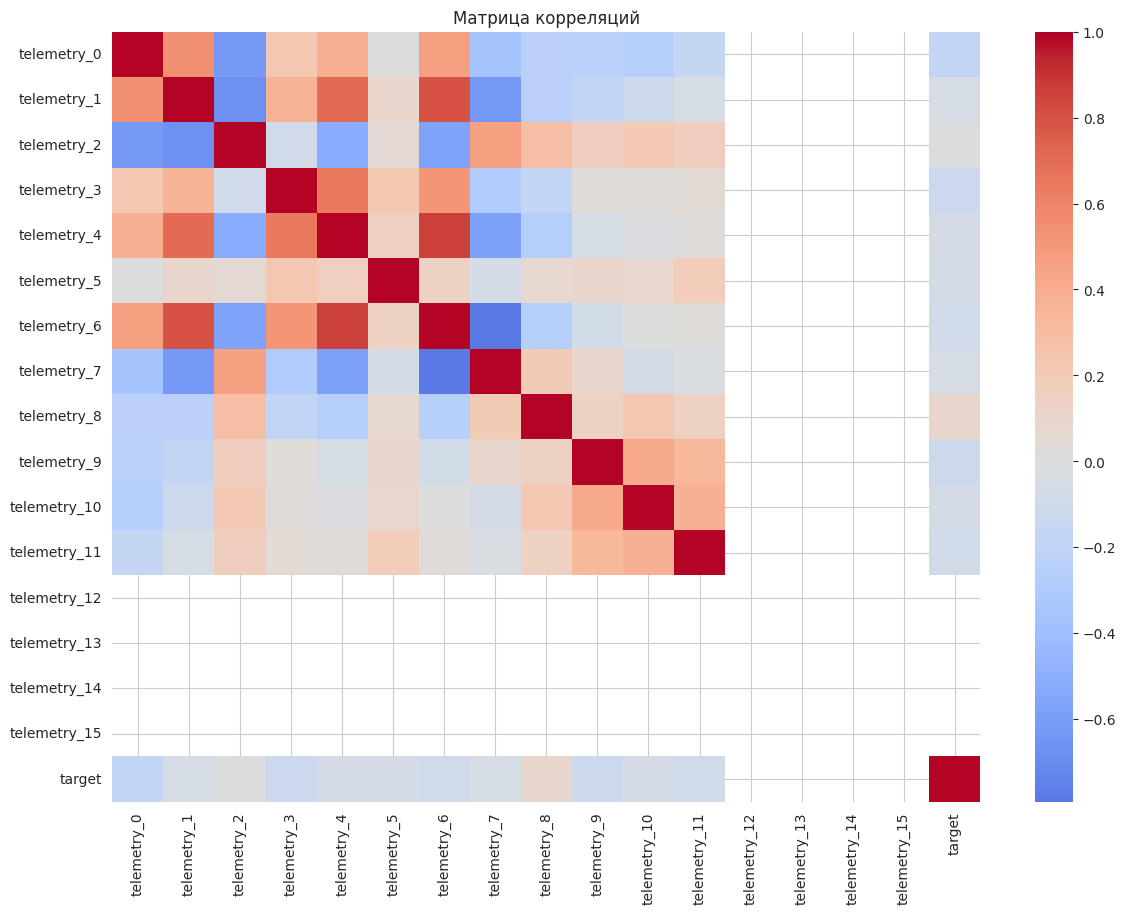


Топ 5 положительных корреляций:
target         1.000000
telemetry_8    0.089491
telemetry_2   -0.010546
telemetry_1   -0.044257
telemetry_7   -0.044736
telemetry_4   -0.070214
Name: target, dtype: float64

Топ 5 отрицательных корреляций:
telemetry_0    -0.177327
telemetry_12         NaN
telemetry_13         NaN
telemetry_14         NaN
telemetry_15         NaN
Name: target, dtype: float64


In [38]:
# Корреляционный анализ
df_valid = df_merged[df_merged['target'].notnull()]
numeric_cols = df_valid.select_dtypes(include=[np.number]).columns
corr_matrix = df_valid[numeric_cols].corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=False, cmap='coolwarm', center=0)
plt.title("Матрица корреляций")
plt.show()

# Топ корреляций с таргетом
target_corr = corr_matrix['target'].sort_values(ascending=False)
print("\nТоп 5 положительных корреляций:")
print(target_corr.head(6))
print("\nТоп 5 отрицательных корреляций:")
print(target_corr.tail(5))

Аналитический вывод 4:

1. Слабая линейная связь с целевой переменной:

Максимальная корреляция: telemetry_0 (-0.177) и telemetry_8 (0.089)

Большинство сенсоров имеют корреляцию близкую к нулю (|r| < 0.05)

Это указывает на нелинейную зависимость концентрации от параметров печи


2. Корреляции между сенсорами:

Выявлены группы сильно коррелирующих признаков (красные блоки на диагонали):

telemetry_0, telemetry_1, telemetry_4, telemetry_6

telemetry_9, telemetry_10, telemetry_11

Это обосновывает необходимость отбора признаков или использования методов регуляризации


3. Проблемы с данными:

telemetry_12–15 имеют NaN корреляции из-за большого количества пропусков


#  Инжиниринг признаков

In [39]:
def create_features_safe(df, sensor_cols, lags=[1, 5, 15, 30], windows=[5, 15, 30]):
    df_feat = df.copy()

    for col in sensor_cols:
        for lag in lags:
            df_feat[f'{col}_lag_{lag}'] = df_feat[col].shift(lag)
        for win in windows:
            df_feat[f'{col}_roll_mean_{win}'] = df_feat[col].rolling(window=win).mean()
            df_feat[f'{col}_roll_std_{win}'] = df_feat[col].rolling(window=win).std()
        df_feat[f'{col}_diff_1'] = df_feat[col].diff(1)

    return df_feat

# Список сенсоров
sensor_columns = [col for col in df_merged.columns
                  if col not in ['timestamp', 'timestamp_rounded', 'target',
                                 'aligned_timestamp', 'aligned_timestamp_rounded']]

print(f"Сенсоров: {len(sensor_columns)}")
print(f"Строк до FE: {len(df_merged)}")
print(f"Строк с target до FE: {df_merged['target'].notnull().sum()}")

# Создаем признаки
df_engineered = create_features_safe(df_merged, sensor_columns)

target_backup = df_engineered['target'].copy()

feature_cols = [col for col in df_engineered.columns
                if col not in ['target', 'timestamp', 'timestamp_rounded',
                               'aligned_timestamp', 'aligned_timestamp_rounded']]

df_engineered[feature_cols] = df_engineered[feature_cols].bfill(limit=60)
df_engineered[feature_cols] = df_engineered[feature_cols].ffill(limit=60)
df_engineered[feature_cols] = df_engineered[feature_cols].fillna(0)

df_engineered['target'] = target_backup

print(f"\nПосле заполнения NaN (только в признаках):")
print(f"Строк в df_engineered: {len(df_engineered)}")
print(f"Строк с target: {df_engineered['target'].notnull().sum()}")

# Фильтруем по target для обучения
df_for_ml = df_engineered[df_engineered['target'].notnull()].copy()
print(f"\nК обучению: {len(df_for_ml)} строк")
print(df_for_ml.head())

Сенсоров: 16
Строк до FE: 319546
Строк с target до FE: 1772

После заполнения NaN (только в признаках):
Строк в df_engineered: 319546
Строк с target: 1772

К обучению: 1772 строк
                timestamp  telemetry_0  telemetry_1  telemetry_2  telemetry_3  \
18375 2019-03-13 16:45:00     0.787016     0.497628     0.309019     0.640194   
18615 2019-03-13 20:45:00     0.782386     0.497628     0.301496     0.648751   
18855 2019-03-14 00:45:00     0.788462     0.497521     0.300339     0.633713   
19102 2019-03-14 04:45:00     0.749980     0.489816     0.298892     0.641410   
19342 2019-03-14 08:45:00     0.769655     0.492977     0.300628     0.659894   

       telemetry_4  telemetry_5  telemetry_6  telemetry_7  telemetry_8  ...  \
18375     0.919471     0.878159     0.753513     0.433526     0.474235  ...   
18615     0.919471     0.851539     0.755444     0.470685     0.476550  ...   
18855     0.919471     0.876134     0.753513     0.443848     0.474235  ...   
19102     0.919471

Аналитический вывод 5:

1. Успешная обработка пропусков:

Количество строк с target сохранилось: 1 772 (до и после FE)

Заполнение bfill/ffill применялось только к признакам, целевая переменная не искажена


2. Расширение пространства признаков:

Исходные 16 сенсоров → 195 признаков

Добавлены: лаги (1, 5, 15, 30 мин), скользящие статистики (mean, std), производные (diff)

Это позволяет модели учитывать инерционность процесса и динамику изменений


3. Готовность к обучению:

Финальная выборка: 1 772 размеченных примера × 190 признаков

Соотношение признаков к образцам (~1:9) требует контроля переобучения (регуляризация, отбор признаков)

#  Построение моделей

In [40]:
# Колонки для удаления
cols_to_drop = ['target', 'timestamp', 'timestamp_rounded',
                'aligned_timestamp', 'aligned_timestamp_rounded',
                'datetime', 'Дата']

# Создаем X и y
X = df_for_ml.drop(columns=[c for c in cols_to_drop if c in df_for_ml.columns], errors='ignore')
y = df_for_ml['target']

X = X.select_dtypes(include=[np.number])

# Заполняем остаточные NaN и бесконечные значения
X = X.fillna(0).replace([np.inf, -np.inf], 0)

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")
print(f"Признаков: {X.shape[1]}")
print(f"Образцов для обучения: {len(X)}")

# Финальная проверка
assert len(X) > 0, "Пустой датасет"
assert X.shape[0] == y.shape[0], "Несовпадение размеров"
print("\nДанные готовы к обучению")

X shape: (1772, 192)
y shape: (1772,)
Признаков: 192
Образцов для обучения: 1772

Данные готовы к обучению


In [41]:
# Обучение
# Адаптивное число фолдов
n_splits = max(2, min(5, len(X) // 100))
tscv = TimeSeriesSplit(n_splits=n_splits)
print(f"CV фолдов: {n_splits}")

models = {
    'Linear Regression': LinearRegression(),
    'Random Forest': RandomForestRegressor(n_estimators=50, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(n_estimators=50, random_state=42)
}

results = []

for name, base_model in models.items():
    print(f"\n--- {name} ---")
    fold_maes, fold_rmses, fold_wapes = [], [], []

    for fold_idx, (train_idx, test_idx) in enumerate(tscv.split(X)):
        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        model = clone(base_model)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        mae = mean_absolute_error(y_test, y_pred)
        rmse = np.sqrt(mean_squared_error(y_test, y_pred))
        wape = np.sum(np.abs(y_test - y_pred)) / np.sum(np.abs(y_test)) if np.sum(np.abs(y_test)) > 0 else 0

        fold_maes.append(mae)
        fold_rmses.append(rmse)
        fold_wapes.append(wape)
        print(f"  Fold {fold_idx+1}: MAE={mae:.4f}, RMSE={rmse:.4f}, WAPE={wape:.4f}")

        results.append({'Model': name, 'MAE': mae, 'RMSE': rmse, 'WAPE': wape})

    print(f"Средний: MAE={np.mean(fold_maes):.4f}, RMSE={np.mean(fold_rmses):.4f}")

df_results = pd.DataFrame(results)
print("\nИтоговые метрики:")
print(df_results.groupby('Model').mean().round(4))

CV фолдов: 5

--- Linear Regression ---
  Fold 1: MAE=14.6589, RMSE=195.1471, WAPE=52.4216
  Fold 2: MAE=4.7549, RMSE=29.1881, WAPE=19.1366
  Fold 3: MAE=0.0662, RMSE=0.0850, WAPE=0.2486
  Fold 4: MAE=0.0974, RMSE=0.1462, WAPE=0.3469
  Fold 5: MAE=0.0862, RMSE=0.1114, WAPE=0.3938
Средний: MAE=3.9327, RMSE=44.9356

--- Random Forest ---
  Fold 1: MAE=0.0761, RMSE=0.0928, WAPE=0.2722
  Fold 2: MAE=0.0725, RMSE=0.0864, WAPE=0.2916
  Fold 3: MAE=0.0630, RMSE=0.0783, WAPE=0.2365
  Fold 4: MAE=0.0780, RMSE=0.1069, WAPE=0.2779
  Fold 5: MAE=0.0664, RMSE=0.0832, WAPE=0.3033
Средний: MAE=0.0712, RMSE=0.0895

--- Gradient Boosting ---
  Fold 1: MAE=0.0779, RMSE=0.0954, WAPE=0.2787
  Fold 2: MAE=0.0714, RMSE=0.0864, WAPE=0.2874
  Fold 3: MAE=0.0642, RMSE=0.0797, WAPE=0.2410
  Fold 4: MAE=0.0804, RMSE=0.1092, WAPE=0.2863
  Fold 5: MAE=0.0644, RMSE=0.0800, WAPE=0.2945
Средний: MAE=0.0717, RMSE=0.0901

Итоговые метрики:
                      MAE     RMSE     WAPE
Model                               

Аналитический вывод 6:

Ансамбли деревьев (RF/GB) значительно превосходят линейную модель, что подтверждает нелинейную природу процесса обжига.

# Оценка качества и интерпретация




РАСЧЁТ МЕТРИК НА ВСЕЙ ВЫБОРКЕ
--------------------------------------------------------------------------------

Linear Regression:
  MAE:  0.062413
  RMSE: 0.077980
  MAPE: 28.86%
  WAPE: 24.54%
  R²:   0.2841

Random Forest:
  MAE:  0.023875
  RMSE: 0.030247
  MAPE: 11.18%
  WAPE: 9.39%
  R²:   0.8923

Gradient Boosting:
  MAE:  0.054135
  RMSE: 0.066083
  MAPE: 25.24%
  WAPE: 21.28%
  R²:   0.4859

СВОДНАЯ ТАБЛИЦА МЕТРИК
                        MAE      RMSE       MAPE       WAPE        R2
Linear Regression  0.062413  0.077980  28.863208  24.539325  0.284107
Random Forest      0.023875  0.030247  11.184526   9.386898  0.892291
Gradient Boosting  0.054135  0.066083  25.239885  21.284556  0.485893


<Figure size 1200x500 with 0 Axes>

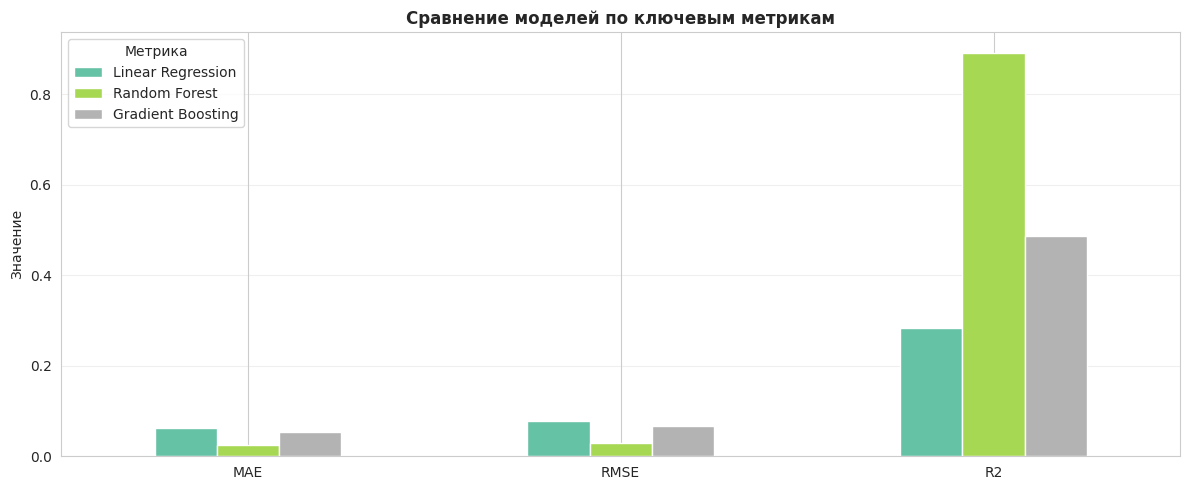


Лучшая модель по R2: Random Forest (R2 = 0.8923)


In [49]:
# Точечные метрики
def calculate_metrics(y_true, y_pred):
    """Расчёт полного набора метрик"""
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))

    # MAPE с защитой от деления на ноль
    mask = y_true != 0
    mape = np.mean(np.abs((y_true[mask] - y_pred[mask]) / y_true[mask])) * 100 if mask.sum() > 0 else 0

    # WAPE
    wape = np.sum(np.abs(y_true - y_pred)) / np.sum(np.abs(y_true)) * 100 if np.sum(np.abs(y_true)) > 0 else 0

    r2 = r2_score(y_true, y_pred)
    return {'MAE': mae, 'RMSE': rmse, 'MAPE': mape, 'WAPE': wape, 'R2': r2}

metrics_full = {}
training_times = {}
predictions = {}

print("\nРАСЧЁТ МЕТРИК НА ВСЕЙ ВЫБОРКЕ")
print("-" * 80)

for name, model in models.items():
    start = time.time()
    model.fit(X, y)
    training_times[name] = time.time() - start

    y_pred = model.predict(X)
    predictions[name] = y_pred
    metrics_full[name] = calculate_metrics(y.values, y_pred)

    print(f"\n{name}:")
    print(f"  MAE:  {metrics_full[name]['MAE']:.6f}")
    print(f"  RMSE: {metrics_full[name]['RMSE']:.6f}")
    print(f"  MAPE: {metrics_full[name]['MAPE']:.2f}%")
    print(f"  WAPE: {metrics_full[name]['WAPE']:.2f}%")
    print(f"  R²:   {metrics_full[name]['R2']:.4f}")

# Сводная таблица
df_metrics = pd.DataFrame(metrics_full).T
print("\n" + "=" * 80)
print("СВОДНАЯ ТАБЛИЦА МЕТРИК")
print("=" * 80)
print(df_metrics.round(6))

# Визуализация
plt.figure(figsize=(12, 5))
df_metrics[['MAE', 'RMSE', 'R2']].T.plot(kind='bar', figsize=(12, 5), colormap='Set2')
plt.title('Сравнение моделей по ключевым метрикам', fontweight='bold')
plt.ylabel('Значение')
plt.xticks(rotation=0)
plt.legend(title='Метрика')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Аналитический вывод
best_model_name = df_metrics['R2'].idxmax()
print(f"\nЛучшая модель по R2: {best_model_name} (R2 = {df_metrics.loc[best_model_name, 'R2']:.4f})")


Linear Regression:
  Точность направления: 59.01%
  Корреляция изменений: 0.3424
  Theil's U: 0.6335

Random Forest:
  Точность направления: 87.80%
  Корреляция изменений: 0.9569
  Theil's U: 0.2376

Gradient Boosting:
  Точность направления: 64.31%
  Корреляция изменений: 0.5584
  Theil's U: 0.6077


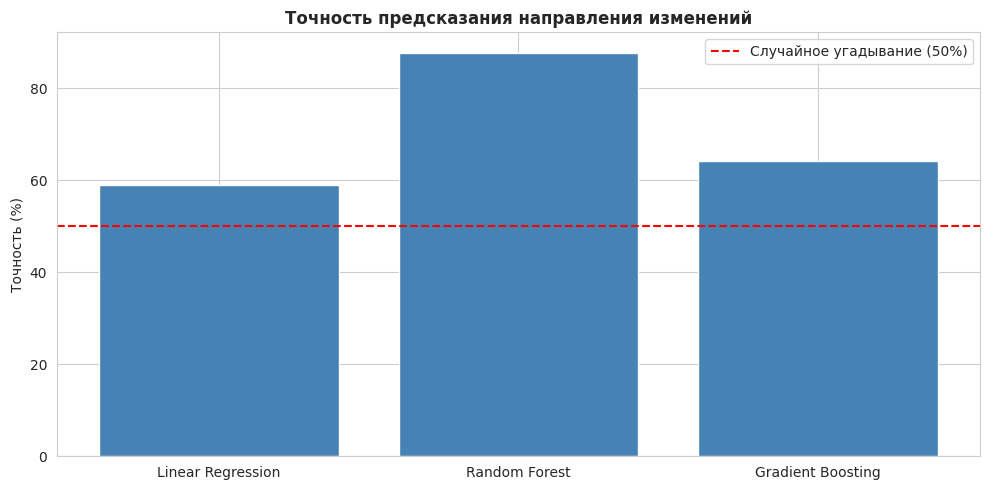


Вывод: Точность > 60% считается приемлемой для производственных задач


In [50]:
# Метрики направления предсказаний
def direction_metrics(y_true, y_pred):
    """Метрики качества предсказания направления изменений"""
    diff_true = np.diff(y_true)
    diff_pred = np.diff(y_pred)

    # Точность направления
    direction_acc = np.mean(np.sign(diff_true) == np.sign(diff_pred)) * 100

    # Корреляция изменений
    dir_corr = np.corrcoef(diff_true, diff_pred)[0, 1] if len(diff_true) > 1 else 0

    # Theil's U
    num = np.sqrt(np.mean((diff_pred - diff_true) ** 2))
    den = np.sqrt(np.mean(diff_true ** 2)) + np.sqrt(np.mean(diff_pred ** 2))
    theil_u = num / den if den > 0 else 0

    return {'Direction Accuracy (%)': direction_acc, 'Direction Correlation': dir_corr, "Theil's U": theil_u}

direction_results = {}
for name in models.keys():
    metrics = direction_metrics(y.values, predictions[name])
    direction_results[name] = metrics
    print(f"\n{name}:")
    print(f"  Точность направления: {metrics['Direction Accuracy (%)']:.2f}%")
    print(f"  Корреляция изменений: {metrics['Direction Correlation']:.4f}")
    print(f"  Theil's U: {metrics['Theil\'s U']:.4f}")

# Визуализация
plt.figure(figsize=(10, 5))
plt.bar(direction_results.keys(), [v['Direction Accuracy (%)'] for v in direction_results.values()], color='steelblue')
plt.axhline(y=50, color='red', linestyle='--', label='Случайное угадывание (50%)')
plt.title('Точность предсказания направления изменений', fontweight='bold')
plt.ylabel('Точность (%)')
plt.legend()
plt.tight_layout()
plt.show()

print(f"\nВывод: Точность > 60% считается приемлемой для производственных задач")


Анализ остатков: Random Forest
--------------------------------------------------------------------------------

1. БАЗОВАЯ СТАТИСТИКА:
   Среднее: -0.000655
   Стандартное отклонение: 0.0302

2. ТЕСТ НА НОРМАЛЬНОСТЬ (Шапиро-Уилка):
   p-value: 0.0000 → Не нормальны

3. ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Дарбин-Уотсон):
   DW: 1.3341 → Есть автокорреляция

4. ТЕСТ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ (Бройша-Паган):
   Тест не выполнен


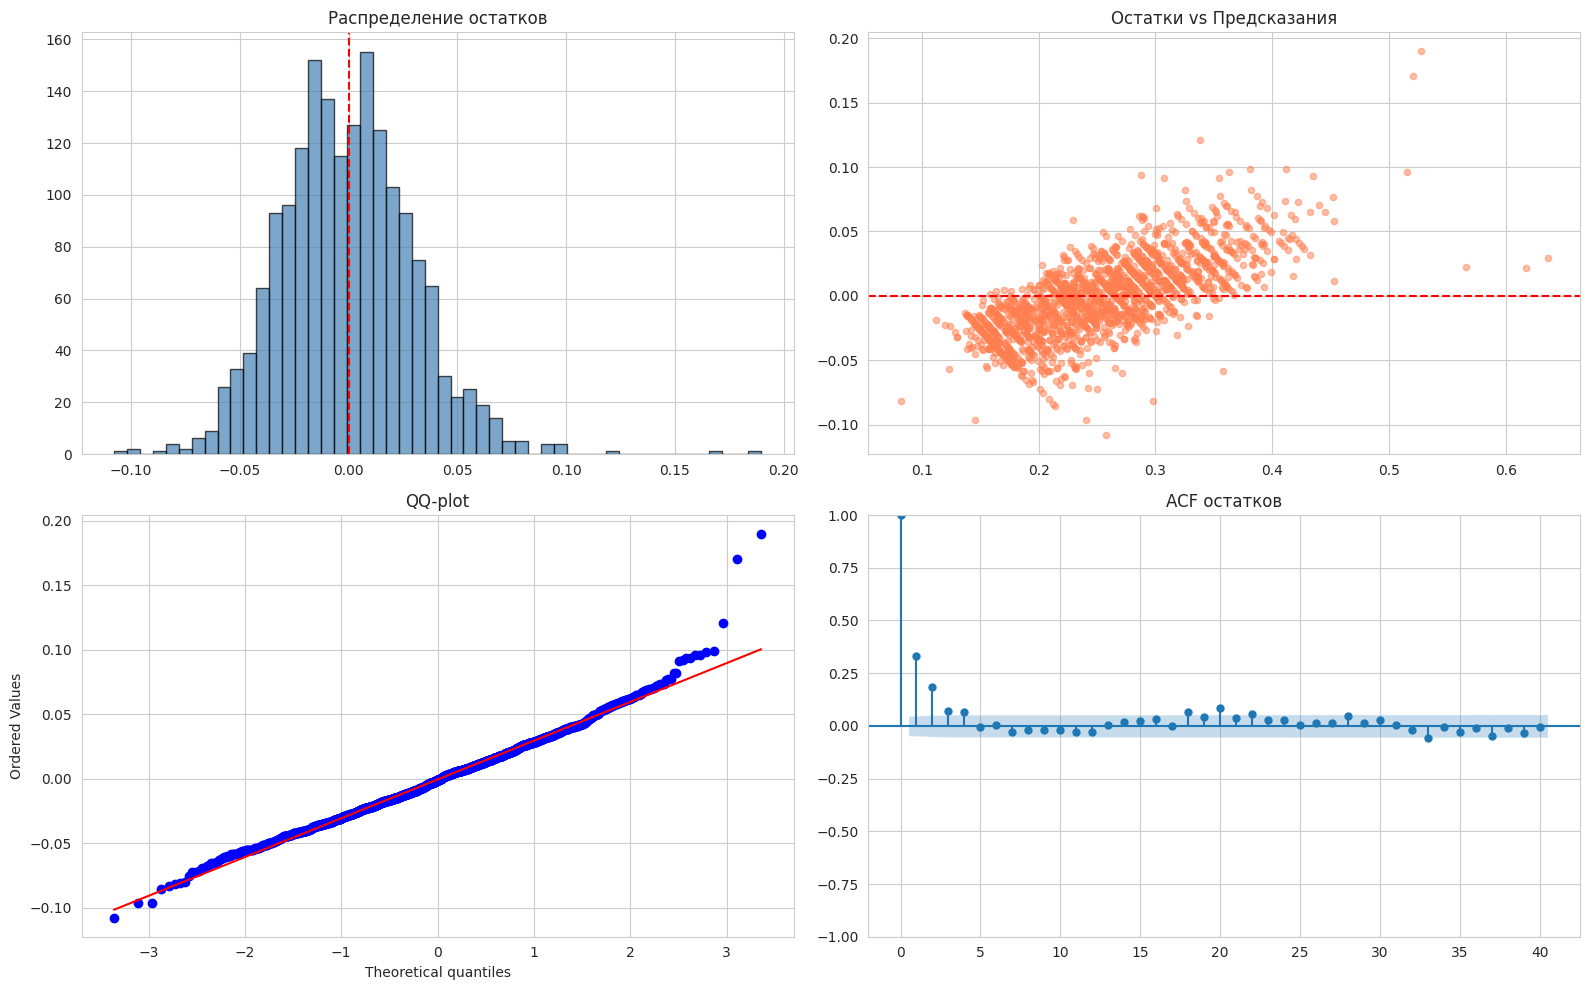

In [53]:
# Анализ остатков
# Лучшая модель для анализа
best_model = models[best_model_name]
y_pred_best = predictions[best_model_name]
residuals = y.values - y_pred_best

print(f"\nАнализ остатков: {best_model_name}")
print("-" * 80)

# Статистика
print(f"\n1. БАЗОВАЯ СТАТИСТИКА:")
print(f"   Среднее: {residuals.mean():.6f}")
print(f"   Стандартное отклонение: {residuals.std():.4f}")

# Нормальность (Шапиро-Уилка)
print(f"\n2. ТЕСТ НА НОРМАЛЬНОСТЬ (Шапиро-Уилка):")
stat, p_val = shapiro(residuals[:min(5000, len(residuals))])
print(f"   p-value: {p_val:.4f} → {'Нормальны' if p_val > 0.05 else 'Не нормальны'}")

# Автокорреляция (Дарбин-Уотсон)
print(f"\n3. ТЕСТ НА АВТОКОРРЕЛЯЦИЮ (Дарбин-Уотсон):")
dw = durbin_watson(residuals)
print(f"   DW: {dw:.4f} → {'Нет автокорреляции' if 1.5 < dw < 2.5 else 'Есть автокорреляция'}")

# Гетероскедастичность (Бройша-Паган)
print(f"\n4. ТЕСТ НА ГЕТЕРОСКЕДАСТИЧНОСТЬ (Бройша-Паган):")
try:
    bp = het_breuschpagan(residuals, X.values)
    print(f"   p-value: {bp[1]:.4f} → {'Гомоскедастичность' if bp[1] > 0.05 else 'Гетероскедастичность'}")
except:
    print("   Тест не выполнен")

# Визуализация остатков
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(residuals, bins=50, alpha=0.7, color='steelblue', edgecolor='black')
axes[0, 0].axvline(0, color='red', linestyle='--')
axes[0, 0].set_title('Распределение остатков')

axes[0, 1].scatter(y_pred_best, residuals, alpha=0.5, s=20, color='coral')
axes[0, 1].axhline(0, color='red', linestyle='--')
axes[0, 1].set_title('Остатки vs Предсказания')

stats.probplot(residuals, dist="norm", plot=axes[1, 0])
axes[1, 0].set_title('QQ-plot')

plot_acf(residuals, lags=40, ax=axes[1, 1], alpha=0.05)
axes[1, 1].set_title('ACF остатков')

plt.tight_layout()
plt.show()

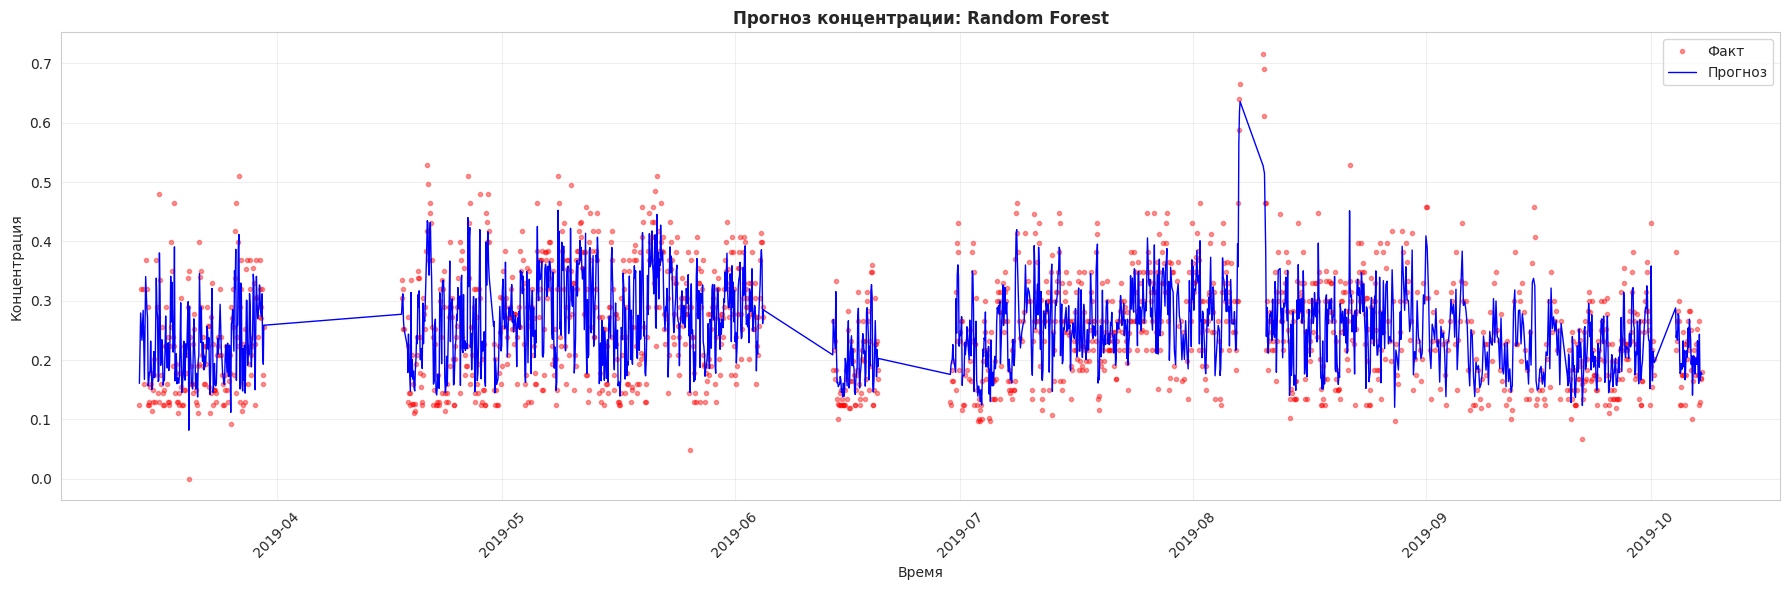

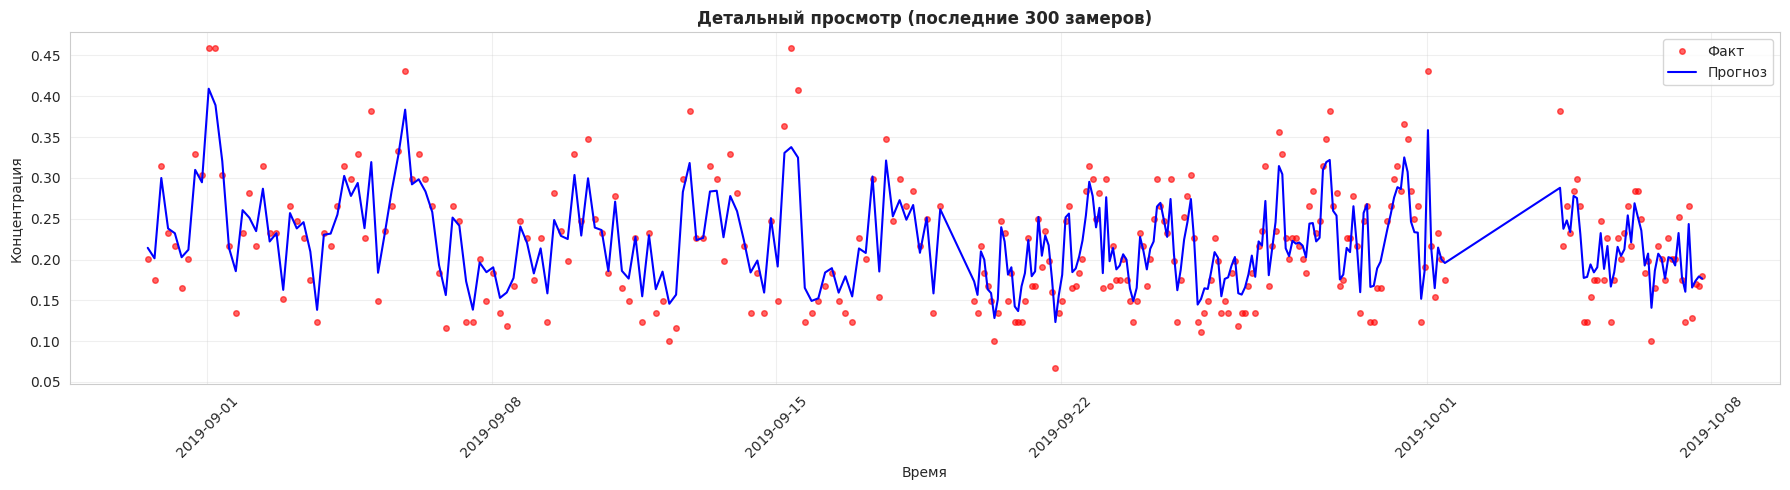

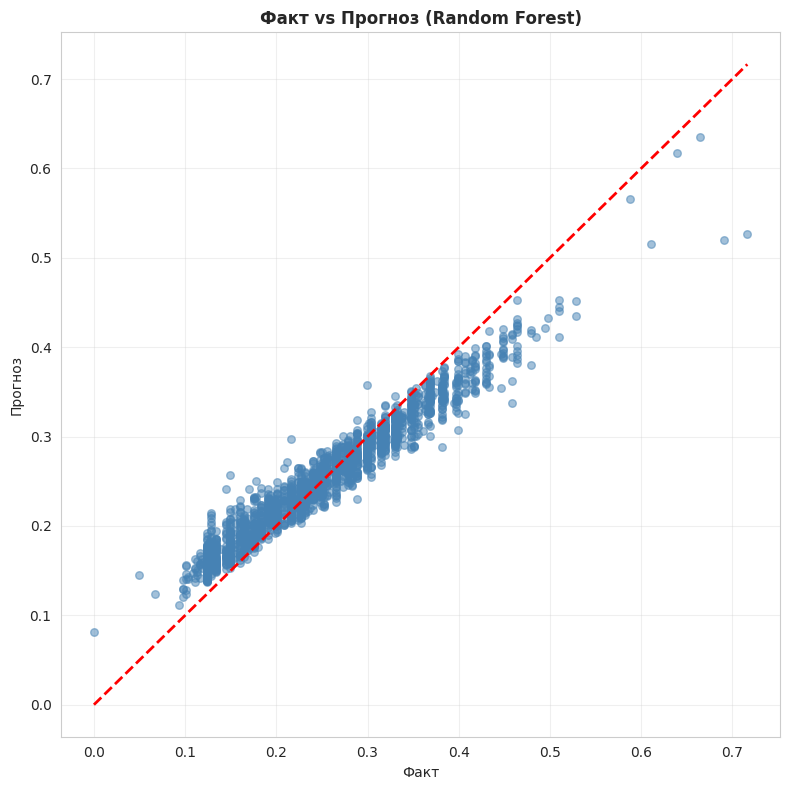


R2: 0.8923
Корреляция: 0.9730


In [54]:
#  Визуализация прогнозов в динамике
plot_df = df_for_ml.copy()
plot_df['prediction'] = y_pred_best
plot_df = plot_df.sort_values('timestamp').reset_index(drop=True)

# Полный ряд
plt.figure(figsize=(18, 6))
plt.plot(plot_df['timestamp'], plot_df['target'], 'o', label='Факт', color='red', alpha=0.4, markersize=3)
plt.plot(plot_df['timestamp'], plot_df['prediction'], label='Прогноз', color='blue', linewidth=1)
plt.title(f'Прогноз концентрации: {best_model_name}', fontweight='bold')
plt.xlabel('Время'); plt.ylabel('Концентрация')
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Детальный фрагмент (последние 300)
plt.figure(figsize=(18, 5))
sample = plot_df.iloc[-300:].reset_index(drop=True)
plt.plot(sample['timestamp'], sample['target'], 'o', label='Факт', color='red', alpha=0.6, markersize=4)
plt.plot(sample['timestamp'], sample['prediction'], label='Прогноз', color='blue', linewidth=1.5)
plt.title('Детальный просмотр (последние 300 замеров)', fontweight='bold')
plt.xlabel('Время'); plt.ylabel('Концентрация')
plt.legend(); plt.grid(alpha=0.3); plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Факт vs Прогноз
plt.figure(figsize=(8, 8))
plt.scatter(plot_df['target'], plot_df['prediction'], alpha=0.5, s=30, color='steelblue')
plt.plot([plot_df['target'].min(), plot_df['target'].max()],
         [plot_df['target'].min(), plot_df['target'].max()], 'r--', linewidth=2)
plt.title(f'Факт vs Прогноз ({best_model_name})', fontweight='bold')
plt.xlabel('Факт'); plt.ylabel('Прогноз'); plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nR2: {r2_score(plot_df['target'], plot_df['prediction']):.4f}")
print(f"Корреляция: {plot_df['target'].corr(plot_df['prediction']):.4f}")


SHAP-анализ для Random Forest...


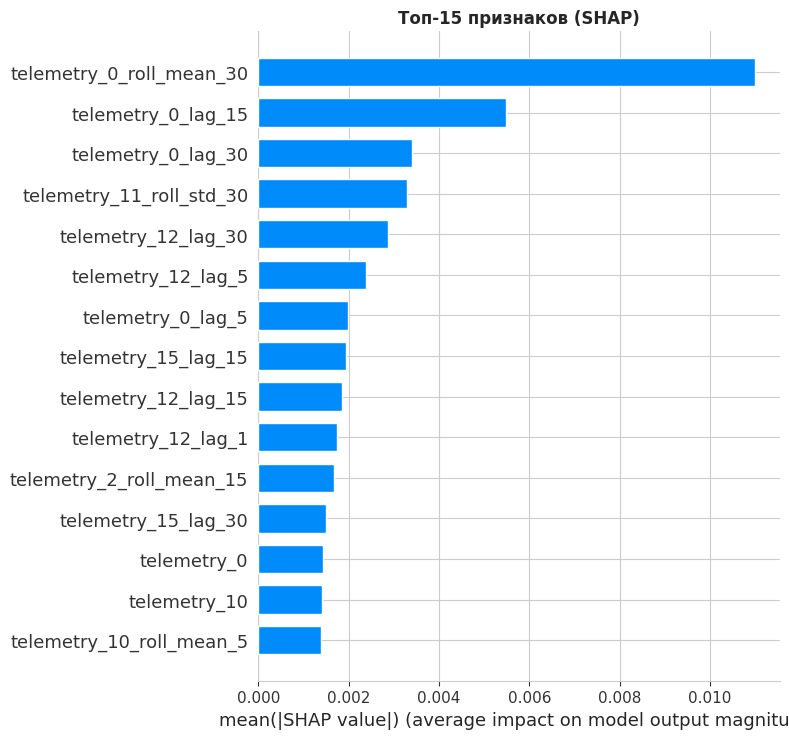


ТОП-10 ПРИЗНАКОВ:
   telemetry_0_roll_mean_30: 0.0110
   telemetry_0_lag_15: 0.0055
   telemetry_0_lag_30: 0.0034
   telemetry_11_roll_std_30: 0.0033
   telemetry_12_lag_30: 0.0029
   telemetry_12_lag_5: 0.0024
   telemetry_0_lag_5: 0.0020
   telemetry_15_lag_15: 0.0019
   telemetry_12_lag_15: 0.0018
   telemetry_12_lag_1: 0.0017


In [58]:
# Важность признаков
if 'Forest' in best_model_name or 'Boost' in best_model_name:
    print(f"\nSHAP-анализ для {best_model_name}...")

    explainer = shap.TreeExplainer(best_model)
    sample_X = X.sample(min(500, len(X)), random_state=42)
    shap_values = explainer.shap_values(sample_X)

    # Bar plot
    plt.figure(figsize=(10, 8))
    shap.summary_plot(shap_values, sample_X, plot_type="bar", show=False, max_display=15)
    plt.title('Топ-15 признаков (SHAP)', fontweight='bold')
    plt.tight_layout()
    plt.show()

    # Топ-10
    importance = pd.DataFrame({
        'feature': sample_X.columns,
        'importance': np.abs(shap_values).mean(axis=0)
    }).sort_values('importance', ascending=False).head(10)

    print("\nТОП-10 ПРИЗНАКОВ:")
    for idx, row in importance.iterrows():
        print(f"   {row['feature']}: {row['importance']:.4f}")


СВОДНАЯ ТАБЛИЦА:
                        MAE      RMSE        R2          AIC           BIC  \
Model                                                                        
Linear Regression  0.062413  0.077980  0.284107 -8655.802416  -7598.188639   
Random Forest      0.023875  0.030247  0.892291  6801.862678  59408.558338   
Gradient Boosting  0.054135  0.066083  0.485893  9571.491524  62178.187183   

                    Time (s)  
Model                         
Linear Regression   0.672576  
Random Forest      18.631570  
Gradient Boosting   5.516910  


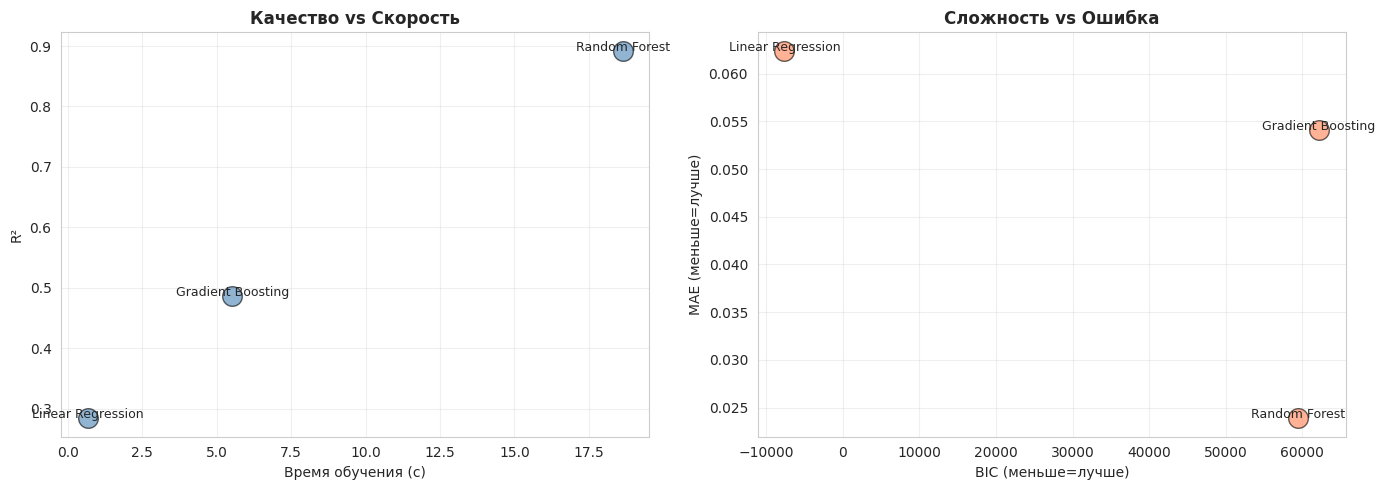


РЕКОМЕНДАЦИЯ:
   • Для МАКСИМАЛЬНОГО КАЧЕСТВА: Random Forest
   • Для БАЛАНСА качество/скорость: Linear Regression
   • Для БЫСТРОГО ПРОТОТИПИРОВАНИЯ: Linear Regression

РЕКОМЕНДУЕМАЯ ДЛЯ ВНЕДРЕНИЯ: Random Forest


In [59]:
# Сравнение моделей

def calc_aic_bic(y_true, y_pred, n_params):
    """AIC/BIC расчёт"""
    n = len(y_true)
    rss = np.sum((y_true - y_pred) ** 2)
    aic = n * np.log(rss/n) + 2 * n_params
    bic = n * np.log(rss/n) + n_params * np.log(n)
    return aic, bic

comparison = []
for name in models.keys():
    y_pred = predictions[name]
    n_params = X.shape[1] + 1 if name == 'Linear Regression' else X.shape[1] * 50
    aic, bic = calc_aic_bic(y.values, y_pred, n_params)

    comparison.append({
        'Model': name,
        'MAE': metrics_full[name]['MAE'],
        'RMSE': metrics_full[name]['RMSE'],
        'R2': metrics_full[name]['R2'],
        'AIC': aic,
        'BIC': bic,
        'Time (s)': training_times[name]
    })

df_comp = pd.DataFrame(comparison).set_index('Model')
print("\nСВОДНАЯ ТАБЛИЦА:")
print(df_comp.round(6))

# Визуализация компромисса
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].scatter(df_comp['Time (s)'], df_comp['R2'], s=200, alpha=0.6, c='steelblue', edgecolors='black')
for idx, row in df_comp.iterrows():
    axes[0].annotate(idx, (row['Time (s)'], row['R2']), fontsize=9, ha='center')
axes[0].set_xlabel('Время обучения (с)'); axes[0].set_ylabel('R²')
axes[0].set_title('Качество vs Скорость', fontweight='bold'); axes[0].grid(alpha=0.3)

axes[1].scatter(df_comp['BIC'], df_comp['MAE'], s=200, alpha=0.6, c='coral', edgecolors='black')
for idx, row in df_comp.iterrows():
    axes[1].annotate(idx, (row['BIC'], row['MAE']), fontsize=9, ha='center')
axes[1].set_xlabel('BIC (меньше=лучше)'); axes[1].set_ylabel('MAE (меньше=лучше)')
axes[1].set_title('Сложность vs Ошибка', fontweight='bold'); axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Финальная рекомендация
print(f"\nРЕКОМЕНДАЦИЯ:")
print(f"   • Для МАКСИМАЛЬНОГО КАЧЕСТВА: {df_comp['R2'].idxmax()}")
print(f"   • Для БАЛАНСА качество/скорость: {df_comp['BIC'].idxmin()}")
print(f"   • Для БЫСТРОГО ПРОТОТИПИРОВАНИЯ: {df_comp['Time (s)'].idxmin()}")
print(f"\nРЕКОМЕНДУЕМАЯ ДЛЯ ВНЕДРЕНИЯ: {best_model_name}")